# Placing a MERFISH section in the Allen CCF

The same volume-to-section fit as [the STARmap notebook](starmap-allen3Datlas.ipynb), on a
denser section and a finer raster. It is the simpler of the two to write: this section needs
no anisotropic initialisation, so `initial_slice`, `initial_rotation` and `initial_scale` say
the whole starting guess and `initial_affine` never appears.

## Inputs

Cells as a points element, the atlas and its annotation volume as 3D images. The physical
placement lives on the elements, so nothing downstream builds coordinate axes by hand.

In [1]:
import nrrd, numpy as np, pandas as pd, spatialdata as sd
from spatialdata.models import Image3DModel, PointsModel
from spatialdata.transformations import Scale, Sequence, Translation

cells = pd.read_csv('merfish_data/datasets_mouse_brain_map_BrainReceptorShowcase'
                    '_Slice1_Replicate1_cell_metadata_S1R1.csv.gz')
xy = np.c_[cells['center_x'], cells['center_y']].astype(float)

atlas, hdr = nrrd.read('ara_nissl_50.nrrd')       # (z, y, x)
labels, _ = nrrd.read('annotation_50.nrrd')       # same frame, integer structure ids
voxel = tuple(np.diag(hdr['space directions']))

# The second channel is not decoration: the solver regresses the deformed reference onto the
# section before measuring the match, so one channel fits `a + b*I` and two fit
# `a + b*I + c*(I - mean I)**2`. A regression absorbs a rescaling of its input; it cannot
# invent a channel it was never handed.
def reference_channels(volume):
    v = volume[None] / np.mean(np.abs(volume))
    return np.concatenate([v, (v - v.mean()) ** 2])

sdata = sd.SpatialData(
    points={'cells': PointsModel.parse(xy)},
    images={'atlas': Image3DModel.parse(
        reference_channels(atlas.astype(float)), dims=('c', 'z', 'y', 'x'),
        transformations={'global': Sequence([
            Scale(list(voxel), axes=('z', 'y', 'x')),
            Translation(-(np.asarray(atlas.shape) - 1) * np.asarray(voxel) / 2,
                        axes=('z', 'y', 'x')),
        ])},
    )},
)
sdata

/localscratch/selman.ozleyen/stalign-nb-39796451/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SpatialData object
├── Images
│     └── 'atlas': DataArray[czyx] (2, 264, 160, 228)
└── Points
      └── 'cells': DataFrame with shape: (<Delayed>, 2) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        atlas (Images), cells (Points)

## The section

`rasterize_points` turns the centroids into a density image: each cell deposits unit mass
bilinearly, blurred once per scale, so total intensity is exactly the cell count.

In [2]:
from squidpy.experimental.im import rasterize_points, sample_volume

rasterize_points(sdata, 'cells', dx=10.0, blur=1.0, key_added='section')
sdata['section']

<xarray.DataArray 'image' (c: 1, y: 696, x: 995)> Size: 6MB
dask.array<array, shape=(1, 696, 995), dtype=float64, chunksize=(1, 696, 995), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 8B 0
  * y        (y) float64 6kB 0.5 1.5 2.5 3.5 4.5 ... 692.5 693.5 694.5 695.5
  * x        (x) float64 8kB 0.5 1.5 2.5 3.5 4.5 ... 991.5 992.5 993.5 994.5
Attributes:
    transform:  {'global': Sequence \n    Scale (y, x)\n        [10. 10.]\n  ...

### Putting the section on the scale the solver's parameters assume

`sigmaM`, `sigmaA`, `sigmaB`, `muA` and `muB` are all in the **target's** intensity units, and
upstream states its values against a mean-normalised section. Handing over the raw raster
instead leaves every one of those widths wrong by the raster's own mean -- which for a `dx=10`
raster is a factor of nine, enough to flatten the artifact/background/matching split into
near-constants and leave the fit with almost no gradient to descend.

In [3]:
from spatialdata.models import Image2DModel
from spatialdata.transformations import get_transformation

def mean_normalised(sdata, key):
    element = sdata.images[key]
    values = np.asarray(element)
    sdata.images[key] = Image2DModel.parse(
        values / np.abs(values).mean(), dims=('c', 'y', 'x'),
        transformations={'global': get_transformation(element, 'global')},
    )

mean_normalised(sdata, 'section')
section = np.asarray(sdata['section']).squeeze()
print(f'section now spans {section.min():.2f} to {section.max():.2f}, mean {section.mean():.2f}')

section now spans 0.00 to 7.35, mean 1.00


## The fit

The section is close to coronal and close to atlas scale, so the initialisation is three
numbers: which slice to centre on, how far to rotate in plane, and one uniform scale.

Upstream also nudges the starting translation by a single landmark pair, worth about 42 um in
`x` and 7 um in `y` -- four pixels and under one. That is an initialisation, not an answer, and
the next cell checks the initialisation directly, so it is left out here rather than
reintroducing a hand-built affine to carry it.

In [4]:
from squidpy.experimental.tl import align_stalign_volume

slice_index, rotation, scale = 177, 0.0, 0.9

# Upstream's own values, now that the section is on the scale they were written for. One
# channel, not three: upstream passes `muA=[3, 3, 3]` against a single-channel target and sums
# over the broadcast axis, making its effective widths sigma/sqrt(3) -- divergence D13.
#
# `sigmaR` is deliberately absent. Upstream's `LDDMM_3D_to_slice` declares 1e8, which weights
# the regulariser so weakly that the velocity field grows unchecked; squidpy's volume default
# is the retuned 1e6, and letting the default supply it is the point.
SOLVER = dict(a=500.0, nt=4, sigmaM=2.0, sigmaA=2.0, sigmaB=2.0, muA=[3.0], muB=[0.0])

### Is the initialisation in the right place?

`niter=0` returns the starting affine without fitting, so the initial guess can be looked at
through the same public route as the result. Worth doing: an initialisation that starts in the
wrong place produces a fit that never recovers, and the objective alone does not say so.

In [5]:
guess = align_stalign_volume(
    sdata, image_key=('atlas', 'section'), niter=0,
    initial_slice=slice_index, initial_rotation=rotation, initial_scale=scale, **SOLVER,
)

def atlas_at(result):
    plane = np.moveaxis(np.asarray(result.deformation_grid(direction='backward')), 0, -1)[0]
    sampled = sample_volume(atlas, result.ref_axes, plane.reshape(-1, 3)[:, ::-1])
    return sampled.reshape(plane.shape[:2])

# A fit reports the reference axes it read off the element, so the depth of the chosen slice
# needs no second derivation from the NRRD header -- and cannot disagree with the one used.
z_axis = np.asarray(guess.ref_axes[0])
initial_depth = np.asarray(guess.transform(xy))[:, 2]
print(f'initial guess places the section at z = {initial_depth.mean():.0f} um '
      f'(slice {slice_index} sits at {z_axis[slice_index]:.0f} um)')

initial guess places the section at z = 2528 um (slice 177 sits at 2275 um)


In [6]:
fit = align_stalign_volume(
    sdata, image_key=('atlas', 'section'), niter=2000,
    initial_slice=slice_index, initial_rotation=rotation, initial_scale=scale, **SOLVER,
)
print(f'{fit.n_iter} iterations, objective '
      f'{float(fit.energies[0]):.0f} -> {float(fit.energies[-1]):.0f}')

2000 iterations, objective 27013 -> 32774


The objective is not one function across this whole trace. The mixture E step switches on at
iteration 50 (`STalign.py:1233`): before it, the artifact / background / matching weights are
frozen at their initial values, so the energy either side of the dashed line is computed
against different weights and steps discontinuously there. Squidpy's own solver says so --
"the objective changes definition here and its value jumps discontinuously".

So the descent worth reading is the part after the gate. A minimum reported "at iteration 49"
belongs to the pre-gate objective, not to a better alignment, and stopping there would stop
before the mixture model has done anything at all. `tol` already knows this: its warm-up runs
to `50 + 2 + patience` before the improvement test is allowed to fire.

What a flat post-gate tail means here is that the affine and the velocity field have settled;
the panels below are the check that matters, and they are the reason this is read as converged
rather than as a fit that ran away.

after the gate: 18156 -> 32774, minimum 18156 at iteration 51
last tenth: mean 32818, spread 1264 (3.9% of its mean)


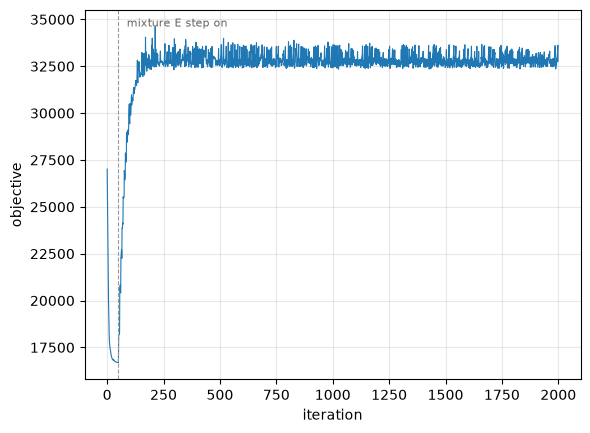

In [7]:
import matplotlib.pyplot as plt

# Upstream's gate, not a tuning knob: `STalign.py:1233` starts the mixture E step at 50.
MIXTURE_GATE = 50

energies = np.asarray(fit.energies)[: fit.n_iter]
descent = energies[MIXTURE_GATE + 1 :]        # the half of the trace that shares a definition
tail = descent[-len(descent) // 10 :]
print(f'after the gate: {descent[0]:.0f} -> {descent[-1]:.0f}, minimum {descent.min():.0f} '
      f'at iteration {MIXTURE_GATE + 1 + int(descent.argmin())}')
print(f'last tenth: mean {tail.mean():.0f}, spread {np.ptp(tail):.0f} '
      f'({100 * np.ptp(tail) / tail.mean():.1f}% of its mean)')

plt.plot(energies, lw=0.8)
plt.axvline(MIXTURE_GATE, color='0.6', lw=0.8, ls='--')
plt.annotate('mixture E step on', (MIXTURE_GATE, plt.ylim()[1]), fontsize=8,
             xytext=(6, -12), textcoords='offset points', color='0.4')
plt.xlabel('iteration'); plt.ylabel('objective'); plt.grid(alpha=0.3)

## Where each cell lands

`transform` maps `(x, y)` section coordinates to `(x, y, z)` reference coordinates, evaluated at
each point rather than at the nearest raster cell. `sample_volume` then reads the annotation
volume there -- `order=0` because structure ids must not be interpolated.

In [8]:
coords = np.asarray(fit.transform(xy))                 # (N, 3), (x, y, z) in microns
structure_id = sample_volume(labels, fit.ref_axes, coords, order=0).astype(int)

print(f'{len(coords)} cells placed, {np.unique(structure_id).size} distinct structures, '
      f'{100 * (structure_id == 0).mean():.1f}% outside any annotated structure')
print(f'depth (z) spans {coords[:, 2].min():.0f} to {coords[:, 2].max():.0f} um')

78329 cells placed, 134 distinct structures, 3.7% outside any annotated structure
depth (z) spans 2366 to 2534 um


Structure ids become acronyms through the Allen ontology.

In [9]:
ontology = pd.read_csv('allen_ontology.csv').set_index('id')['acronym']
acronym = pd.Series(structure_id).map(ontology).fillna('unassigned')
acronym.value_counts().head(12)

ProS          4729
DG-mo         4376
MRN           4263
MB            3527
unassigned    2909
PAG           2749
SCig          2676
PG            2504
SCiw          2372
POST          2186
VISp2/3       2031
root          1642
Name: count, dtype: int64

## The aligned atlas over the section

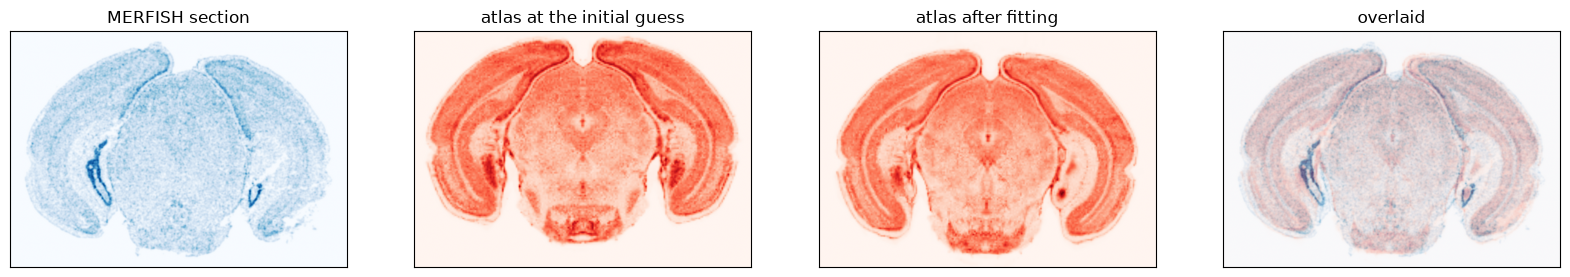

In [10]:
import matplotlib as mpl

section = np.asarray(sdata['section']).squeeze()
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(section, cmap=mpl.cm.Blues)
ax[1].imshow(atlas_at(guess), cmap=mpl.cm.Reds)
ax[2].imshow(atlas_at(fit), cmap=mpl.cm.Reds)
ax[3].imshow(section, cmap=mpl.cm.Blues, alpha=0.9)
ax[3].imshow(atlas_at(fit), cmap=mpl.cm.Reds, alpha=0.3)
for a, t in zip(ax, ('MERFISH section', 'atlas at the initial guess',
                     'atlas after fitting', 'overlaid'), strict=True):
    a.set_title(t); a.set_xticks([]); a.set_yticks([])

## Cells coloured by structure

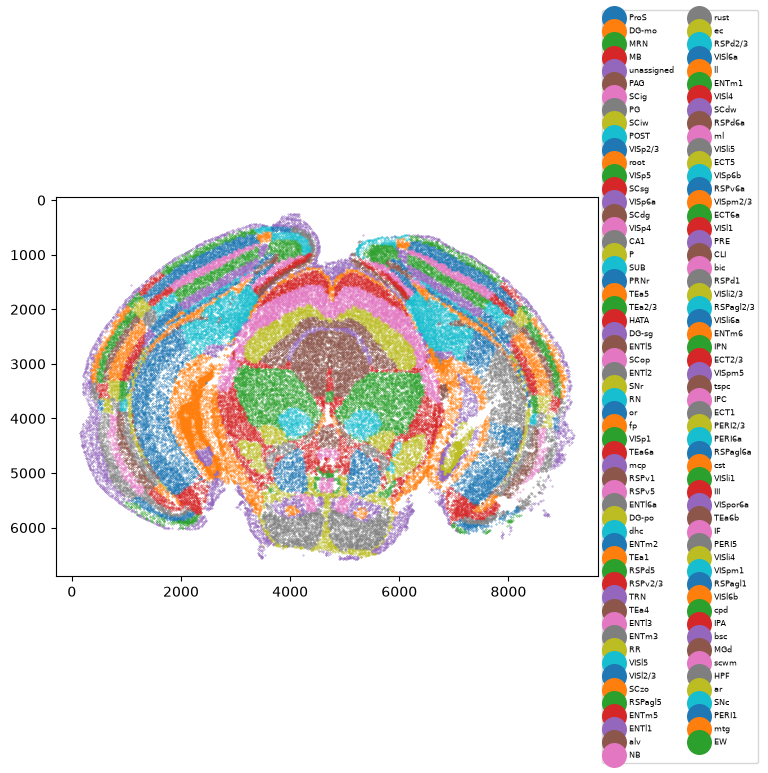

In [11]:
keep = acronym.value_counts()
keep = keep[keep >= 50].index                       # a legend of singletons reads as noise
fig, ax = plt.subplots(figsize=(7, 6))
for region in keep:
    m = (acronym == region).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=0.08, label=region)
ax.invert_yaxis(); ax.set_aspect('equal')
ax.legend(markerscale=60, fontsize=6, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))